Final Project

Research Question: “Which factor, age, income, or education, is the strongest predictor of voter turnout in Charlotte-Mecklenburg in 2020 when all three are considered together?” 

A functioning democracy depends on voter turnout, and low turnout is linked to political disengagement, which makes this issue crucial. It adds to the general perception that choosing a candidate won't significantly change public policy. Determining the variables that affect voter participation will also aid in figuring out how to approach that group and boost it.

** Voter turnout measures the percentage of voters who have actually taken part in the election (proportion of eligible voters who actually cast a vote). 


In [188]:
%pip install pandas numpy seaborn scikit-learn ucimlrepo -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV,  StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc
from ucimlrepo import fetch_ucirepo


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [189]:
df = pd.read_csv('/Users/bizyc/Documents/DTSC/2301/Final Project/Charlotte-Mecklenburg-cs.csv')

In [190]:
df

,NPA,AllOtherRaces,HispanicorLatino,BlackorAfrican,WhiteorCas,Asian,AverageAge,AgeYouth,AgeEdler,VoterParticipation2020,HouseholdIncome,BachlelorsDegree,Highschool Diploma
0,2.0,0.07,0.11,0.21,0.60,0.02,33,0.27,0.07,0.71,75084.00,0.35,0.94
1,3.0,0.04,0.05,0.07,0.79,0.05,30,0.11,0.09,0.75,117630.00,0.85,0.98
2,4.0,0.03,0.03,0.02,0.88,0.04,43,0.38,0.10,0.87,250001.00,0.89,1.00
3,5.0,0.05,0.12,0.71,0.11,0.01,30,0.23,0.02,0.47,49539.00,0.03,0.79
4,6.0,0.04,0.10,0.71,0.15,0.01,42,0.19,0.18,0.53,37907.00,0.21,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,473.0,0.05,0.10,0.15,0.88,0.03,--,0.15,0.15,0.79,72313.00,0.51,0.96
456,474.0,0.05,0.04,0.03,0.68,0.02,--,0.18,0.22,0.76,135929.00,0.64,1.00
457,475.0,0.04,0.02,0.01,0.86,0.02,--,0.27,0.18,0.85,211250.00,0.84,0.96
458,476.0,0.05,0.07,0.22,0.92,0.08,30,0.06,0.07,0.62,100040.00,0.63,0.95


In [191]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

NPA: 459 unique values
AllOtherRaces: 11 unique values
HispanicorLatino: 56 unique values
BlackorAfrican: 85 unique values
WhiteorCas: 93 unique values
Asian: 36 unique values
AverageAge: 40 unique values
AgeYouth: 47 unique values
AgeEdler: 41 unique values
VoterParticipation2020: 50 unique values
HouseholdIncome: 442 unique values
BachlelorsDegree: 94 unique values
Highschool Diploma: 47 unique values


In [192]:
df

,NPA,AllOtherRaces,HispanicorLatino,BlackorAfrican,WhiteorCas,Asian,AverageAge,AgeYouth,AgeEdler,VoterParticipation2020,HouseholdIncome,BachlelorsDegree,Highschool Diploma
0,2.0,0.07,0.11,0.21,0.60,0.02,33,0.27,0.07,0.71,75084.00,0.35,0.94
1,3.0,0.04,0.05,0.07,0.79,0.05,30,0.11,0.09,0.75,117630.00,0.85,0.98
2,4.0,0.03,0.03,0.02,0.88,0.04,43,0.38,0.10,0.87,250001.00,0.89,1.00
3,5.0,0.05,0.12,0.71,0.11,0.01,30,0.23,0.02,0.47,49539.00,0.03,0.79
4,6.0,0.04,0.10,0.71,0.15,0.01,42,0.19,0.18,0.53,37907.00,0.21,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,473.0,0.05,0.10,0.15,0.88,0.03,--,0.15,0.15,0.79,72313.00,0.51,0.96
456,474.0,0.05,0.04,0.03,0.68,0.02,--,0.18,0.22,0.76,135929.00,0.64,1.00
457,475.0,0.04,0.02,0.01,0.86,0.02,--,0.27,0.18,0.85,211250.00,0.84,0.96
458,476.0,0.05,0.07,0.22,0.92,0.08,30,0.06,0.07,0.62,100040.00,0.63,0.95


In [193]:
X = df.drop(columns=['VoterParticipation2020'])
y = df['VoterParticipation2020']

In [194]:
X

,NPA,AllOtherRaces,HispanicorLatino,BlackorAfrican,WhiteorCas,Asian,AverageAge,AgeYouth,AgeEdler,HouseholdIncome,BachlelorsDegree,Highschool Diploma
0,2.0,0.07,0.11,0.21,0.60,0.02,33,0.27,0.07,75084.00,0.35,0.94
1,3.0,0.04,0.05,0.07,0.79,0.05,30,0.11,0.09,117630.00,0.85,0.98
2,4.0,0.03,0.03,0.02,0.88,0.04,43,0.38,0.10,250001.00,0.89,1.00
3,5.0,0.05,0.12,0.71,0.11,0.01,30,0.23,0.02,49539.00,0.03,0.79
4,6.0,0.04,0.10,0.71,0.15,0.01,42,0.19,0.18,37907.00,0.21,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...
455,473.0,0.05,0.10,0.15,0.88,0.03,--,0.15,0.15,72313.00,0.51,0.96
456,474.0,0.05,0.04,0.03,0.68,0.02,--,0.18,0.22,135929.00,0.64,1.00
457,475.0,0.04,0.02,0.01,0.86,0.02,--,0.27,0.18,211250.00,0.84,0.96
458,476.0,0.05,0.07,0.22,0.92,0.08,30,0.06,0.07,100040.00,0.63,0.95


In [195]:
y

0      0.71
1      0.75
2      0.87
3      0.47
4      0.53
       ... 
455    0.79
456    0.76
457    0.85
458    0.62
459     NaN
Name: VoterParticipation2020, Length: 460, dtype: str

In [196]:
y.head()

0    0.71
1    0.75
2    0.87
3    0.47
4    0.53
Name: VoterParticipation2020, dtype: str

Section 2: Data Cleaning

In [197]:
X.isnull().sum()

NPA                   1
AllOtherRaces         1
HispanicorLatino      1
BlackorAfrican        1
WhiteorCas            1
Asian                 1
AverageAge            1
AgeYouth              1
AgeEdler              1
HouseholdIncome       1
BachlelorsDegree      1
Highschool Diploma    1
dtype: int64

In [198]:
df

,NPA,AllOtherRaces,HispanicorLatino,BlackorAfrican,WhiteorCas,Asian,AverageAge,AgeYouth,AgeEdler,VoterParticipation2020,HouseholdIncome,BachlelorsDegree,Highschool Diploma
0,2.0,0.07,0.11,0.21,0.60,0.02,33,0.27,0.07,0.71,75084.00,0.35,0.94
1,3.0,0.04,0.05,0.07,0.79,0.05,30,0.11,0.09,0.75,117630.00,0.85,0.98
2,4.0,0.03,0.03,0.02,0.88,0.04,43,0.38,0.10,0.87,250001.00,0.89,1.00
3,5.0,0.05,0.12,0.71,0.11,0.01,30,0.23,0.02,0.47,49539.00,0.03,0.79
4,6.0,0.04,0.10,0.71,0.15,0.01,42,0.19,0.18,0.53,37907.00,0.21,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,473.0,0.05,0.10,0.15,0.88,0.03,--,0.15,0.15,0.79,72313.00,0.51,0.96
456,474.0,0.05,0.04,0.03,0.68,0.02,--,0.18,0.22,0.76,135929.00,0.64,1.00
457,475.0,0.04,0.02,0.01,0.86,0.02,--,0.27,0.18,0.85,211250.00,0.84,0.96
458,476.0,0.05,0.07,0.22,0.92,0.08,30,0.06,0.07,0.62,100040.00,0.63,0.95


In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NPA                     459 non-null    float64
 1   AllOtherRaces           459 non-null    str    
 2   HispanicorLatino        459 non-null    str    
 3   BlackorAfrican          459 non-null    str    
 4   WhiteorCas              459 non-null    str    
 5   Asian                   459 non-null    str    
 6   AverageAge              459 non-null    str    
 7   AgeYouth                459 non-null    str    
 8   AgeEdler                459 non-null    str    
 9   VoterParticipation2020  459 non-null    str    
 10  HouseholdIncome         459 non-null    str    
 11  BachlelorsDegree        459 non-null    str    
 12  Highschool Diploma      459 non-null    str    
dtypes: float64(1), str(12)
memory usage: 46.8 KB


In [200]:
df.head()

,NPA,AllOtherRaces,HispanicorLatino,BlackorAfrican,WhiteorCas,Asian,AverageAge,AgeYouth,AgeEdler,VoterParticipation2020,HouseholdIncome,BachlelorsDegree,Highschool Diploma
0,2.0,0.07,0.11,0.21,0.60,0.02,33,0.27,0.07,0.71,75084.00,0.35,0.94
1,3.0,0.04,0.05,0.07,0.79,0.05,30,0.11,0.09,0.75,117630.00,0.85,0.98
2,4.0,0.03,0.03,0.02,0.88,0.04,43,0.38,0.10,0.87,250001.00,0.89,1.00
3,5.0,0.05,0.12,0.71,0.11,0.01,30,0.23,0.02,0.47,49539.00,0.03,0.79
4,6.0,0.04,0.10,0.71,0.15,0.01,42,0.19,0.18,0.53,37907.00,0.21,0.78


In [201]:
# Check for outliers:
def find_outliers(col_name, df):
    # This function identifies the number of outliers in a given column using the Tukey Definition
    # Calculate IQR
    q1=np.percentile(df[col_name], 25)
    q3=np.percentile(df[col_name], 75)
    iqr=q3-q1

    # Calculate Threshold and bounds
    threshold=1.5*iqr
    
    lb=q1-threshold
    ub=q3+threshold

    # Identify outliers
    outliers = np.where((df[col_name] < lb) | (df[col_name] > q3 + ub))

    return len(outliers)

In [202]:
# Count outliers in each column
def find_outliers(col_name, df):
    col = pd.to_numeric(df[col_name], errors='coerce')  # convert bad values to NaN

    q1 = np.percentile(col.dropna(), 25)
    q3 = np.percentile(col.dropna(), 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = col[(col < lower) | (col > upper)]
    return len(outliers)

In [203]:
df['VoterParticipation2020'] = df['VoterParticipation2020']

In [204]:
df['VoterParticipation2020']

0      0.71
1      0.75
2      0.87
3      0.47
4      0.53
       ... 
455    0.79
456    0.76
457    0.85
458    0.62
459     NaN
Name: VoterParticipation2020, Length: 460, dtype: str

Section 3: Exploring The Data

Text(0, 0.5, 'Frequency')

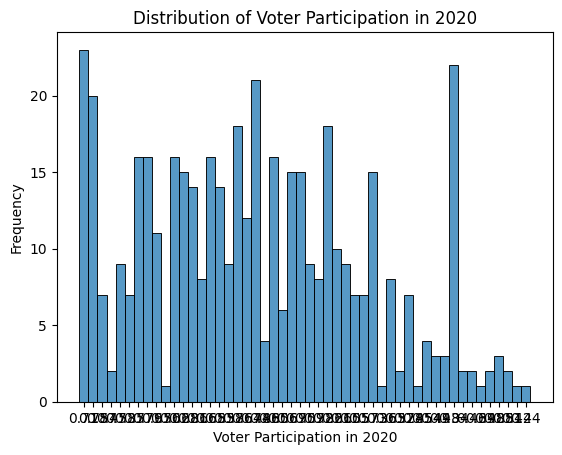

In [205]:
sns.histplot(y)
plt.title('Distribution of Voter Participation in 2020')
plt.xlabel('Voter Participation in 2020')
plt.ylabel('Frequency')

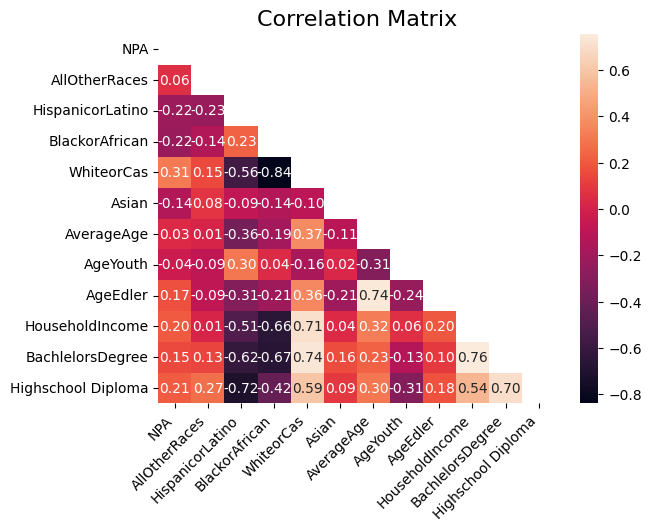

In [206]:
corr_mat = X.replace('--', np.nan).corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt=".2f", mask=mask)
plt.xticks(rotation=45, ha='right')   # Tilt labels for better fit
plt.title("Correlation Matrix", fontsize=16)
plt.show()

From the correlation Matrix its clear that there are some varriables that are similar like average age and age youth and age elder. There for I decided to drop average age. However Household income and bachelors degree , and white and house hold income also show a high correlation.

In [207]:
print(type(y))
print(y.head())

<class 'pandas.Series'>
0    0.71
1    0.75
2    0.87
3    0.47
4    0.53
Name: VoterParticipation2020, dtype: str


In [208]:
from collections import Counter
Counter(y)

Counter({'0.71': 23,
         '0.84': 22,
         '0.74': 21,
         '0.75': 20,
         '0.76': 18,
         '0.82': 18,
         '0.77': 16,
         '0.79': 16,
         '0.62': 16,
         '0.65': 16,
         '0.80': 16,
         '0.68': 15,
         '0.69': 15,
         '0.70': 15,
         '0.73': 15,
         '0.81': 14,
         '0.83': 14,
         '0.64': 12,
         '0.67': 11,
         '0.61': 10,
         '0.53': 9,
         '0.58': 9,
         '0.59': 9,
         '0.60': 9,
         '0.66': 8,
         '0.72': 8,
         '0.63': 8,
         '0.87': 7,
         '0.85': 7,
         '0.55': 7,
         '0.57': 7,
         '0.78': 7,
         '0.56': 6,
         '0.86': 4,
         '0.54': 4,
         '0.49': 3,
         '0.43': 3,
         '0.88': 3,
         '0.47': 2,
         '0.52': 2,
         '--': 2,
         '0.46': 2,
         '0.48': 2,
         '0.51': 2,
         '0.50': 1,
         '0.36': 1,
         '0.45': 1,
         '0.39': 1,
         '0.42': 1,
  

Part 4: Feature Engineering and Preprocessing

In [209]:
# Map y from strings to numbers and extract values
y_data = y.values.ravel()

In [210]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_data, train_size=0.8, random_state=42
)

In [211]:
# Scaling Features using Robust Scaling
rs_scaler = RobustScaler()

# 3. Fit ONLY on the Training data, then transform both
# This ensures the 'Robust' parameters are calculated using ONLY train info
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

train_valid = X_train.notna().all(axis=1)
test_valid = X_test.notna().all(axis=1)
X_train = X_train.loc[train_valid]
X_test = X_test.loc[test_valid]
y_train = y_train[train_valid]
y_test = y_test[test_valid]

X_train_scaled = rs_scaler.fit_transform(X_train)
X_test_scaled = rs_scaler.transform(X_test) # Use .transform, NOT .fit_transform here

# 4. Optional: Convert back to DataFrame
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Part 5: Models

In [212]:
# Initialize Cross-Validation Rules
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [213]:
# Method 1: Linear Regression
# Initialize Model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

# Perform 5-fold cross validation using "r2" as metric of choice
lr_scores = cross_val_score(lr_model, X_train_df, y_train, cv=5, scoring="r2")
print("Linear Regression Fold Scores:", lr_scores)
print("Linear Regression Mean R² Score:", np.mean(lr_scores))

Linear Regression Fold Scores: [0.68521507 0.74909134 0.58702895 0.73561568 0.74487797]
Linear Regression Mean R² Score: 0.70036580332433


In [214]:
# Convert continuous target to binary classification (high vs low turnout)
# Using median as threshold
y_train = pd.to_numeric(y_train, errors="coerce")
y_test = pd.to_numeric(y_test, errors="coerce")

median_turnout = np.nanmedian(y_train)
y_train_binary = (y_train >= median_turnout).astype(int)
y_test_binary = (y_test >= median_turnout).astype(int)

# Method 2: Elastic Net Logistic Regression
# Initialize Model
lr_en_model = LogisticRegression(penalty="elasticnet", solver="saga", max_iter=10000)

# Define Hyperparameter Grid
param_grid = {"C": np.logspace(-3, 2, 6), # [0.001, 0.01, 0.1, 1, 10, 100]
              "l1_ratio": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]}

grid_search = GridSearchCV(
    estimator=lr_en_model, param_grid=param_grid, cv=skf, scoring="roc_auc"
)

# 5. Execute the search
grid_search.fit(X_train_df, y_train_binary)

en_best_params=grid_search.best_params_
en_best_score=grid_search.best_score_
# Print best parameters
print(f"Best Parameters: {en_best_params}")
print(f"Best Cross-Validation ROC AUC Score: {en_best_score:.4f}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Best Parameters: {'C': np.float64(1.0), 'l1_ratio': 0.9}
Best Cross-Validation ROC AUC Score: 0.9542


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [215]:
# Method 3: Decision Trees
# 1. Initialize the Decision Tree Model, set max_depth to 5 as default
dt_model = DecisionTreeClassifier(max_depth=5, random_state=2)

# Perform 5-fold cross-validation using scaled data and binary target
dt_scores = cross_val_score(dt_model, X_train_df, y_train_binary, cv=skf, scoring='roc_auc')

# Output results
print(f"Decision Tree Fold Scores: {dt_scores}")
print(f"Mean ROC AUC Score: {dt_scores.mean():.4f}")

Decision Tree Fold Scores: [0.78456221 0.78686636 0.85483871 0.87096774 0.87142857]
Mean ROC AUC Score: 0.8337


Part 6: Model Evaluation and Feature Importance

Part 6.1: Model Evaluation

In [216]:
# Train the best Elastic Net Logistic Regression model with best parameters
best_lr_model = LogisticRegression(C=en_best_params['C'], l1_ratio=en_best_params['l1_ratio'], 
								   penalty="elasticnet", solver="saga", max_iter=10000)
best_lr_model.fit(X_train_df, y_train_binary)

# Make predictions on the testing data
y_pred_binary = best_lr_model.predict(X_test_df)
y_prob = best_lr_model.predict_proba(X_test_df)[:, 1] # Probability for the positive class

# Calculate the Test ROC AUC
test_roc_auc = roc_auc_score(y_test_binary, y_prob)

# Print the results
print(f"Test ROC AUC Score: {test_roc_auc:.4f}")

Test ROC AUC Score: 0.9614


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


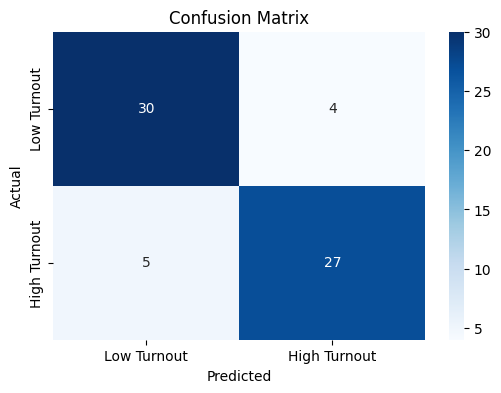

In [217]:
cm = confusion_matrix(y_test_binary, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Turnout', 'High Turnout'], 
            yticklabels=['Low Turnout', 'High Turnout'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

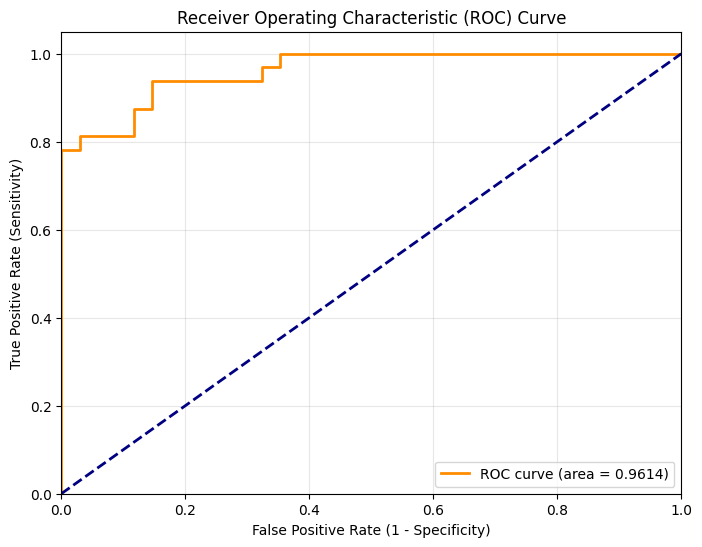

In [218]:
#ROC Curve
# Calculate FPR, TPR, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Part 6.2 Feature Importance

In [219]:
# Fit the linear regression model before accessing coef_
lr_model.fit(X_train_df, y_train)

importance_df = pd.DataFrame(
    {
        "Feature": list(X_train_df.columns),
        "Weight": lr_model.coef_.flatten(),
        "Absolute_Weight": abs(lr_model.coef_.flatten()),
    }
)

# Sort by sheer pulling power of the variable
importance_df = importance_df.sort_values(by="Absolute_Weight", ascending=False)
importance_df

# Sort by sheer pulling power of the variable
importance_df = importance_df.sort_values(by="Absolute_Weight", ascending=False)
importance_df

,Feature,Weight,Absolute_Weight
3,BlackorAfrican,-0.068004,0.068004
9,HouseholdIncome,0.033767,0.033767
2,HispanicorLatino,-0.031451,0.031451
4,WhiteorCas,-0.026350,0.026350
6,AverageAge,0.023569,0.023569
11,Highschool Diploma,0.018022,0.018022
7,AgeYouth,0.013129,0.013129
8,AgeEdler,0.012786,0.012786
5,Asian,-0.008898,0.008898
10,BachlelorsDegree,0.005138,0.005138


Text(0.5, 1.0, 'Feature Importance')

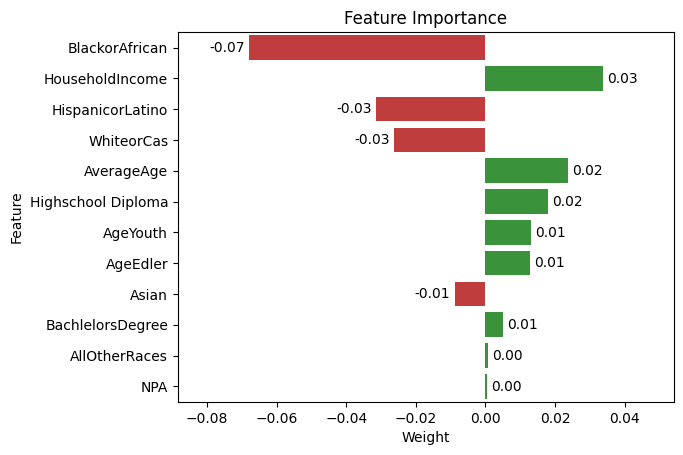

In [220]:
# Assign colors: green for positive impact and red for negative impact
color = ["#2ca02c" if x > 0 else "#d62728" for x in importance_df["Weight"]]

# create Bar Plot
ax = sns.barplot(
    data=importance_df,
    x="Weight",
    y="Feature",
    palette=color,
    hue="Feature",
    legend=False,
)

# Show amounts in bars without overlapping with axis values
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%.2f")

ax.margins(x=0.2)
plt.title("Feature Importance")

Through this feature importance graph you are able to see that education, age, and income are the 3 major factors as our research question suggest but this feature importance shows the th emost important feature is household income since it is the largest however there is not much of gap between the other major varriables only being a .01 difference for AverageAge and a .02 difference for BachelorsDegree.

In [221]:
fi = clf.feature_importances_ #feature importance array
fi = pd.Series(data=fi, index=features)
fi.sort_values(ascending=False, inplace=True) #sort descending

/var/folders/4m/_1m73ky117b10vpzt0hh78480000gn/T/ipykernel_1131/3876163039.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


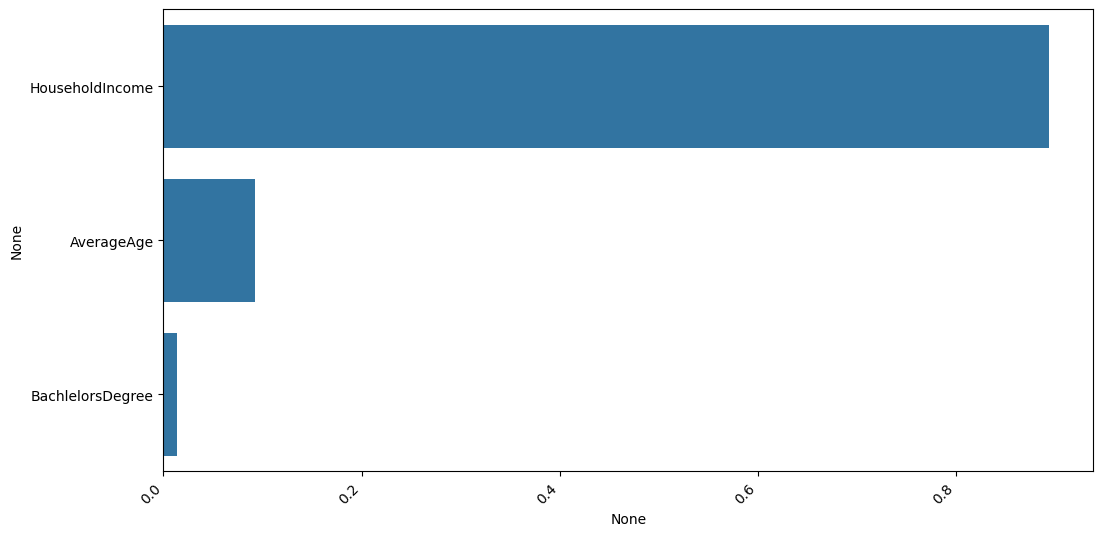

In [222]:
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

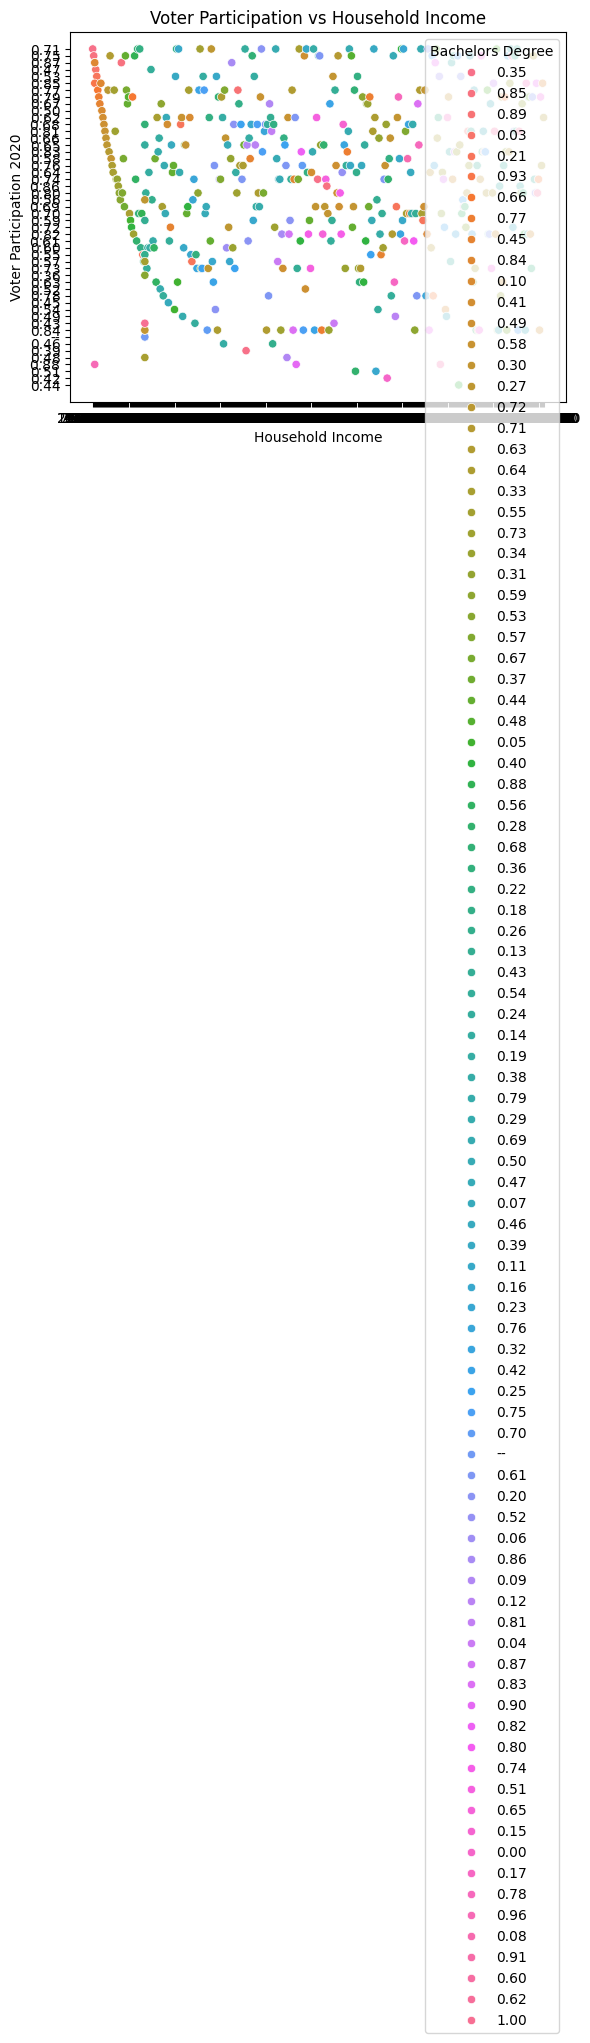

In [223]:
sns.scatterplot(data=df, x='HouseholdIncome', y='VoterParticipation2020', hue='BachlelorsDegree')
plt.title('Voter Participation vs Household Income')
plt.xlabel('Household Income')
plt.ylabel('Voter Participation 2020')
plt.legend(title='Bachelors Degree')
plt.show()
plt.show()


DecisionTreeRegressor

In [224]:
# 1. Clean data to ensure it's numeric for models
cols = ['AverageAge', 'HouseholdIncome', 'BachlelorsDegree', 'VoterParticipation2020']
for col in cols:
    df[col] = pd.to_numeric(df[col].replace('--', np.nan), errors='coerce')

# 2. Drop missing values so models don't crash
df_clean = df[cols].dropna()

# 3. Define target and features
X = df_clean[['AverageAge', 'HouseholdIncome', 'BachlelorsDegree']]
y = df_clean['VoterParticipation2020']

# 4. Standardize for Linear Regression (Required to compare "strength")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [225]:
# 1. Select your specific research features and clean
features = ['AverageAge', 'HouseholdIncome', 'BachlelorsDegree']
target = 'VoterParticipation2020'

# Ensure numeric types (Handling the '--' and strings from your snippet)
for col in features + [target]:
    df[col] = pd.to_numeric(df[col].replace('--', np.nan), errors='coerce')

# Drop rows with NaN to keep the experiment clean
df_final = df[features + [target]].dropna()

In [226]:
X = df_final[features]


In [227]:
y = df_final[target]


In [228]:
from sklearn.tree import DecisionTreeRegressor

# 2. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Experiment: Decision Tree Regressor
# We set max_depth to prevent overfitting (good reasoning for your report!)
# 2. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Experiment: Decision Tree Regressor
# We set max_depth to prevent overfitting (good reasoning for your report!)
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [229]:
# 3. Evaluate (Using Regression Metrics)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")


Root Mean Squared Error: 0.0704
R-squared Score: 0.4872
Root Mean Squared Error: 0.0704
R-squared Score: 0.4872


In [230]:
# 4. Identify the Strongest Predictor
importances = pd.Series(dt_model.feature_importances_, index=features)
print("\n--- Feature Importance Results ---")
print(importances.sort_values(ascending=False))


--- Feature Importance Results ---
HouseholdIncome     0.894120
AverageAge          0.092255
BachlelorsDegree    0.013625
dtype: float64


According to the DecisionTreeRegressor the most important feature is house hold income coming in at .894120. and the BachelorsDegree is the lowest of the three at .013625

Decision Tree

In [231]:
dt_model.score(X_test, y_test)

0.4871680994058081

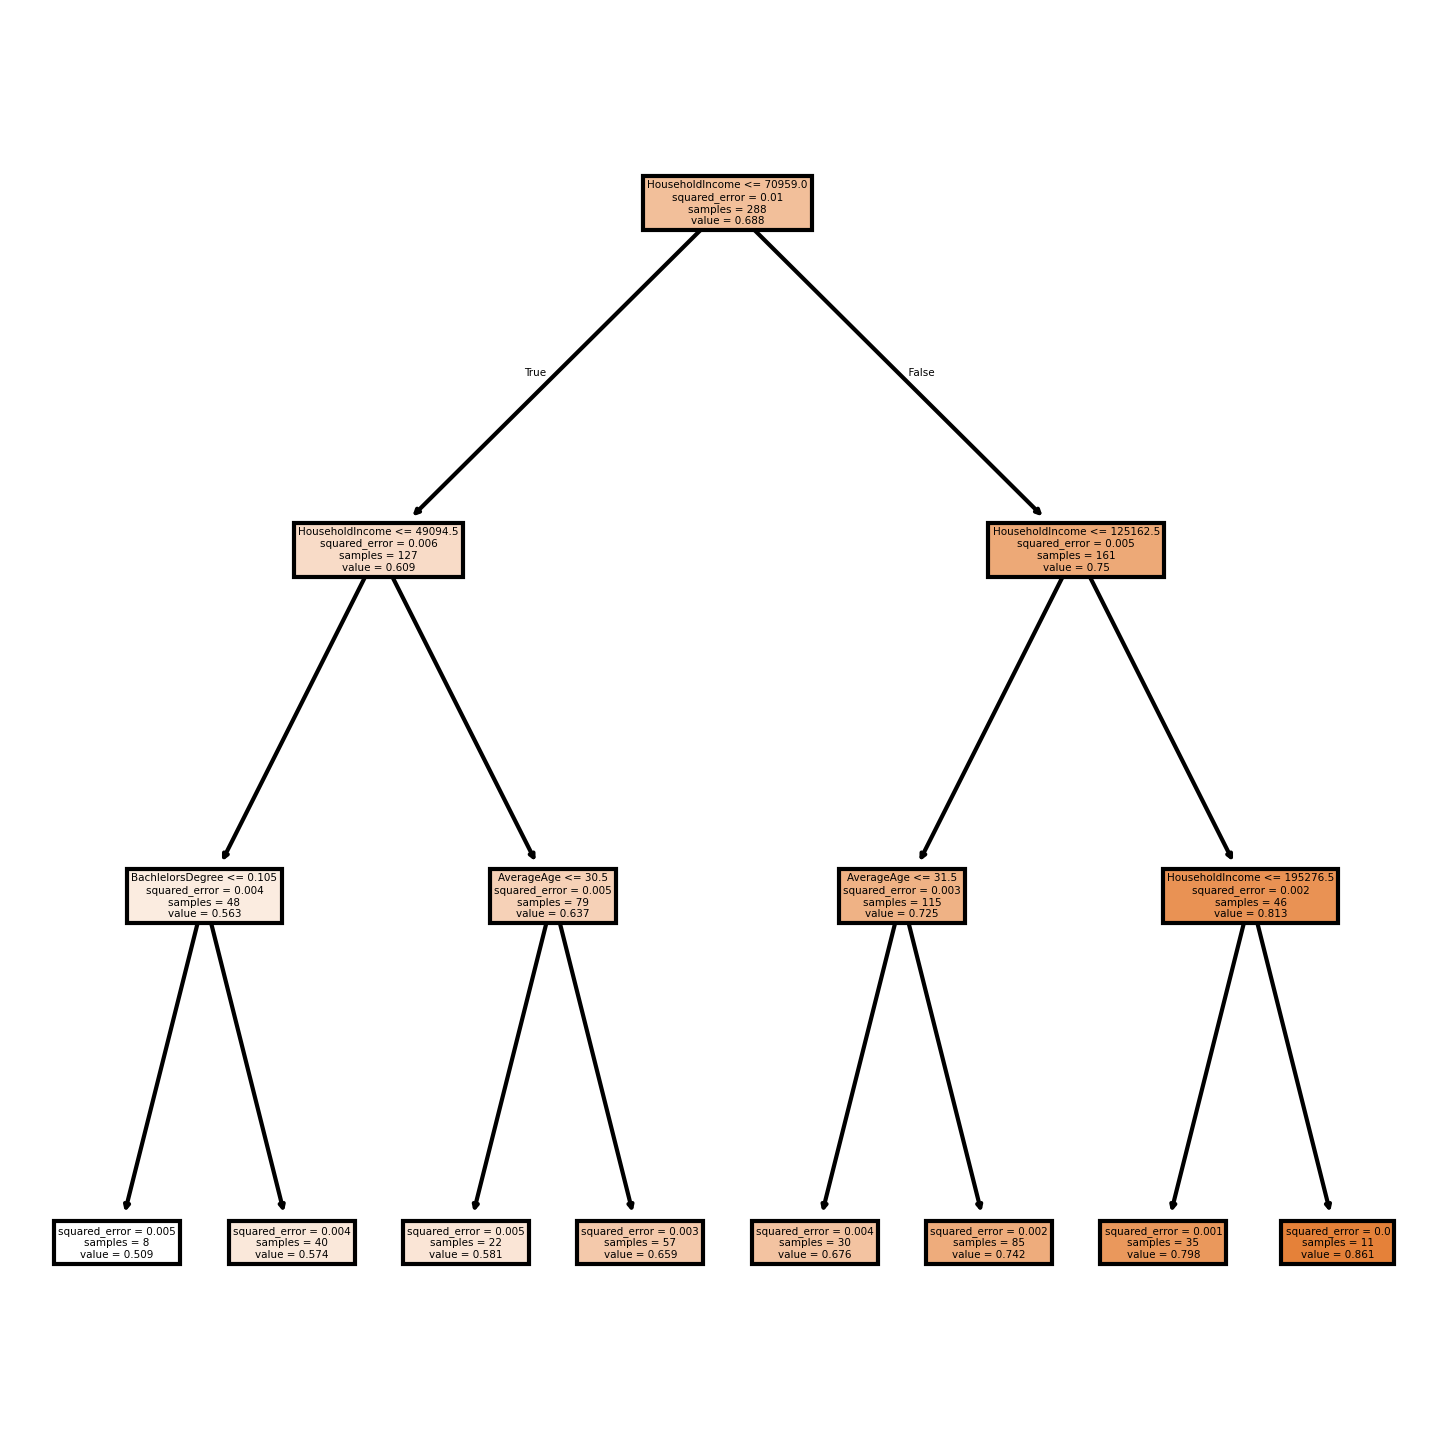

In [232]:
from sklearn import tree

clf = dt_model

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)
tree.plot_tree(clf, max_depth=3, feature_names=X.columns, filled=True, ax=axes)
plt.show()


Random Forest Model

In [233]:
# 1. Prepare and Clean Data (Crucial for handling the '--' and strings)
features = ['AverageAge', 'HouseholdIncome', 'BachlelorsDegree']
target = 'VoterParticipation2020'

for col in features + [target]:
    df[col] = pd.to_numeric(df[col].replace('--', np.nan), errors='coerce')

df_clean = df[features + [target]].dropna()

In [234]:
X = df_clean[features]


In [235]:
y = df_clean[target]


In [236]:
# 2. Split Data (Keep it consistent for all models)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [237]:
from sklearn.ensemble import RandomForestRegressor

# 3. Train Random Forest
# We use 100 trees (n_estimators) to ensure stable results
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [238]:
# 4. Evaluate Performance
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest R-squared: {r2:.4f}")

Random Forest RMSE: 0.0606
Random Forest R-squared: 0.6205


In [239]:
# 5. Extract Feature Importance (This answers your Research Question)
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Strongest Predictors (Random Forest) ---")
print(importances)


--- Strongest Predictors (Random Forest) ---
HouseholdIncome     0.722985
AverageAge          0.162155
BachlelorsDegree    0.114860
dtype: float64


This random forest model once again showed that the strongest predictor is HouseholdIncome at .722985. BachelorsDegree is the weakest predictor at .114860